<a href="https://colab.research.google.com/github/samikshanimje/SmartECG-HD/blob/main/notebooks/05_inference_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os
import sys
import importlib

PROJECT_ROOT = "/content/drive/MyDrive/SmartECG-HD"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

sys.modules.pop("src", None)
sys.modules.pop("src.config", None)

importlib.invalidate_caches()

from src.config import *

In [8]:
import numpy as np
import joblib

from tensorflow.keras.models import load_model

In [9]:
model = load_model(BEST_MODEL_PATH)

encoder = joblib.load(
    os.path.join(MODEL_DIR, "label_encoder.pkl")
)

print("✅ Model Loaded")
print("✅ Label Encoder Loaded")

✅ Model Loaded
✅ Label Encoder Loaded


In [10]:
beats = np.load(BEATS_PATH)["beats"]

labels = np.load(LABELS_PATH)

print(beats.shape)

(109380, 300)


In [11]:
sample = beats[0]

sample = sample.reshape(1,300,1)

print(sample.shape)

(1, 300, 1)


In [12]:
prediction = model.predict(sample)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
[[1.6447881e-07 9.9985719e-01 7.4040281e-07 1.4179657e-04 6.9840453e-08]]


In [13]:
predicted_index = np.argmax(prediction)

predicted_class = encoder.inverse_transform([predicted_index])[0]

confidence = prediction[0][predicted_index] * 100

print("Prediction :", predicted_class)
print("Confidence :", confidence)

Prediction : N
Confidence : 99.98572


In [14]:
probabilities = {}

for i, label in enumerate(encoder.classes_):

    probabilities[label] = float(prediction[0][i] * 100)

probabilities

{np.str_('F'): 1.6447880625491962e-05,
 np.str_('N'): 99.9857177734375,
 np.str_('Q'): 7.404028292512521e-05,
 np.str_('S'): 0.014179657213389874,
 np.str_('V'): 6.984045285207685e-06}

In [15]:
result = {

    "prediction": predicted_class,

    "confidence": round(confidence,2),

    "probabilities": probabilities

}

result

{'prediction': np.str_('N'),
 'confidence': np.float32(99.99),
 'probabilities': {np.str_('F'): 1.6447880625491962e-05,
  np.str_('N'): 99.9857177734375,
  np.str_('Q'): 7.404028292512521e-05,
  np.str_('S'): 0.014179657213389874,
  np.str_('V'): 6.984045285207685e-06}}

In [18]:
#BONUS
def predict_ecg(ecg_signal):

    ecg_signal = np.array(ecg_signal).reshape(1,300,1)

    prediction = model.predict(ecg_signal, verbose=0)

    index = np.argmax(prediction)

    label = encoder.inverse_transform([index])[0]

    confidence = float(prediction[0][index] * 100)

    probabilities = {}

    for i, cls in enumerate(encoder.classes_):
        probabilities[cls] = float(prediction[0][i] * 100)

    return {
        "prediction": label,
        "confidence": round(confidence,2),
        "probabilities": probabilities
    }

In [19]:
output = predict_ecg(beats[10])

output

{'prediction': np.str_('N'),
 'confidence': 99.99,
 'probabilities': {np.str_('F'): 4.13400812249165e-06,
  np.str_('N'): 99.98503875732422,
  np.str_('Q'): 2.641978198880679e-06,
  np.str_('S'): 0.014960227534174919,
  np.str_('V'): 2.0327615857240744e-06}}

In [20]:
INFERENCE_DIR = os.path.join(PROJECT_ROOT, "inference")
os.makedirs(INFERENCE_DIR, exist_ok=True)

In [21]:
import json
import os

report = {

    "prediction": predicted_class,

    "confidence": float(confidence),

    "probabilities": probabilities

}

with open(
    os.path.join(INFERENCE_DIR, "prediction.json"),
    "w"
) as f:

    json.dump(report, f, indent=4)

print("✅ Prediction Saved")

✅ Prediction Saved


In [22]:
np.save(
    os.path.join(INFERENCE_DIR, "input_signal.npy"),
    sample
)

print("✅ ECG Saved")

✅ ECG Saved


In [23]:
np.save(
    os.path.join(INFERENCE_DIR, "prediction_vector.npy"),
    prediction
)

print("✅ Softmax Output Saved")

✅ Softmax Output Saved


In [24]:
import pandas as pd

pd.DataFrame(

    probabilities.items(),

    columns=["Class","Probability"]

).to_csv(

    os.path.join(
        INFERENCE_DIR,
        "probabilities.csv"
    ),

    index=False
)

In [31]:
import matplotlib.pyplot as plt


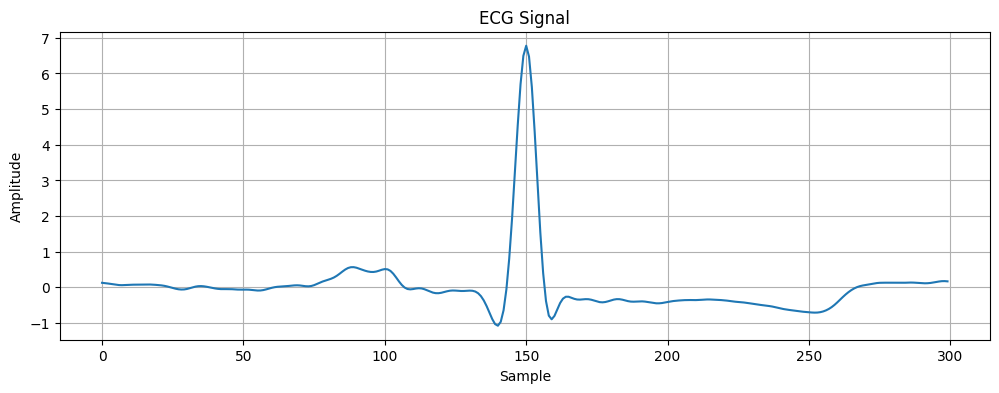

In [32]:
plt.figure(figsize=(12,4))

plt.plot(sample.flatten())

plt.title("ECG Signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.grid(True)

plt.savefig(
    os.path.join(
        INFERENCE_DIR,
        "ecg_signal.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
print("="*50)

print("Inference Files")

print("="*50)

for file in os.listdir(INFERENCE_DIR):

    print(file)

print("="*50)

Inference Files
prediction.json
input_signal.npy
prediction_vector.npy
probabilities.csv
ecg_signal.png
